In [52]:
import os
os.getcwd()


'C:\\Users\\LAP\\Documents\\GitHub\\ml-heart-disease-assignment'

In [53]:
import numpy as np

In [54]:
import pandas as pd

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [56]:
# Load heart disease dataset
data = pd.read_csv("heart.csv")

In [57]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [58]:
# Display all column names
print("Columns in dataset:")
print(data.columns)

Columns in dataset:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [59]:
data.shape

(1025, 14)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [61]:
# Display summary statistics
print("Statistical Summary:")
print(data.describe())

Statistical Summary:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.

In [62]:
# Check missing values in each column
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [63]:
# Count duplicate rows
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 723


In [64]:
# Remove duplicate rows
data = data.drop_duplicates()

# Check new shape after removing duplicates
print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (302, 14)


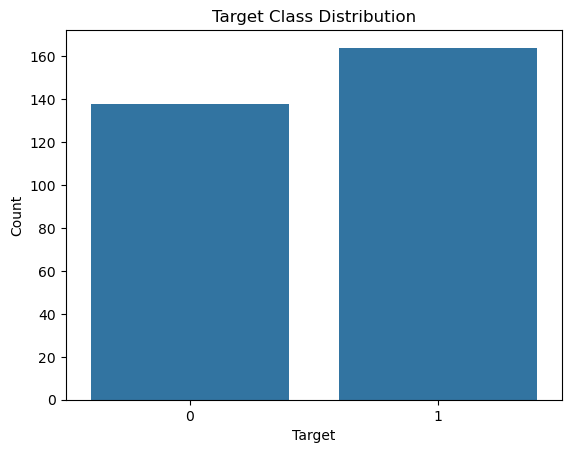

In [65]:
# Visualize target class distribution
sns.countplot(x="target", data=data)
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

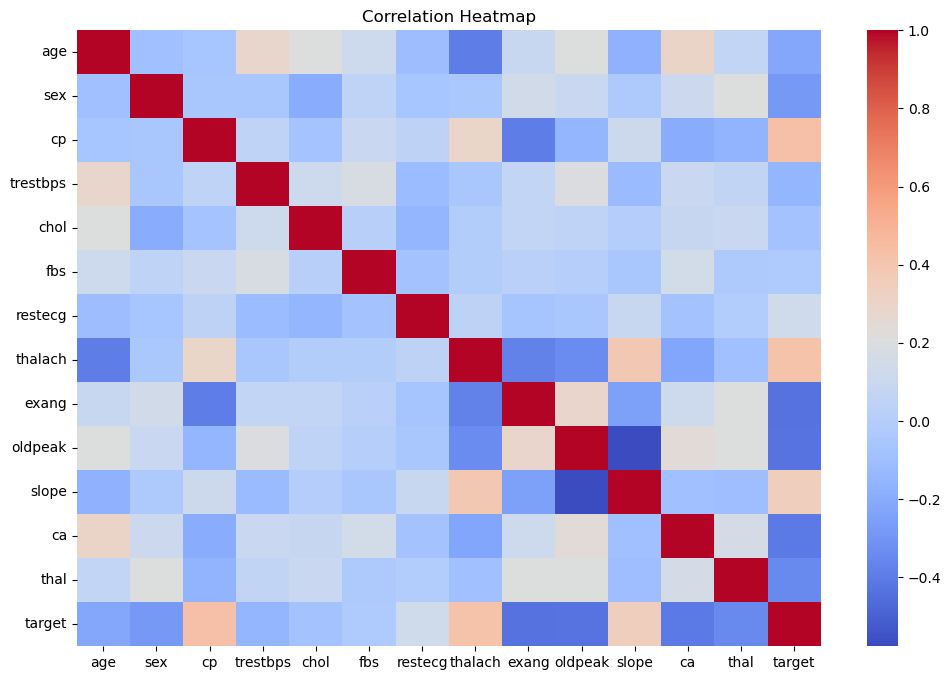

In [66]:
# Calculate correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [67]:
# Separate input features and output target
X = data.drop("target", axis=1)
y = data["target"]

# Display shape of X and y
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (302, 13)
Target vector shape: (302,)


In [68]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes of split data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


In [69]:
# Create StandardScaler object
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [70]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [71]:
X_train_scaled_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
1,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
2,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
3,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
4,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643


In [72]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve


In [73]:
# Initialize and train SVM with RBF kernel
# RBF (Radial Basis Function) kernel works well for non-linear data
svm_model = SVC(
    kernel='rbf',       # RBF kernel for non-linear classification
    C=1.0,              # regularization parameter
    gamma='scale',      # kernel coefficient
    probability=True,   # enable probability estimates (needed for ROC curve)
    random_state=42
)

svm_model.fit(X_train, y_train)
print('SVM model trained successfully!')

SVM model trained successfully!


In [74]:
# Save cleaned dataset
data.to_csv("dataset/processed/heart_cleaned.csv", index=False)

print("Processed dataset saved.")

Processed dataset saved.


In [75]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

In [76]:
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [77]:
svm_pred = svm_model.predict(X_test_scaled)

In [78]:
print("===== SVM Evaluation =====")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))

===== SVM Evaluation =====
Accuracy: 0.7704918032786885
Precision: 0.7714285714285715
Recall: 0.8181818181818182
F1 Score: 0.7941176470588235


In [79]:
svm_cm = confusion_matrix(y_test, svm_pred)
print("Confusion Matrix:")
print(svm_cm)

Confusion Matrix:
[[20  8]
 [ 6 27]]


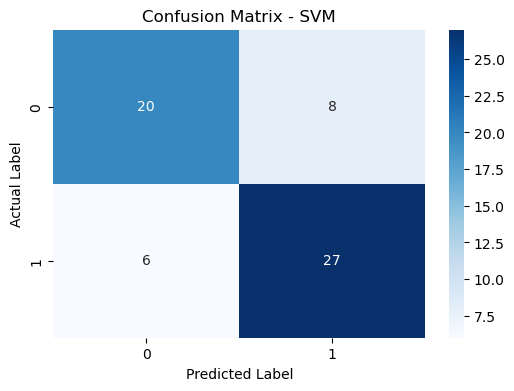

In [80]:
plt.figure(figsize=(6,4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [81]:
print("Classification Report:")
print(classification_report(y_test, svm_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [82]:
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_auc = roc_auc_score(y_test, svm_prob)
print("ROC-AUC Score:", svm_auc)

ROC-AUC Score: 0.841991341991342


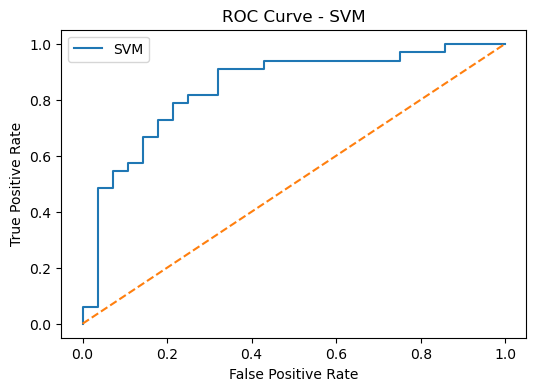

In [83]:
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_prob)

plt.figure(figsize=(6,4))
plt.plot(svm_fpr, svm_tpr, label="SVM")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}
grid_search_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search_svm.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search_svm.best_params_)
print("Best Cross Validation Score:", grid_search_svm.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross Validation Score: 0.8297619047619047


In [86]:
best_svm_model = grid_search_svm.best_estimator_

In [87]:
best_svm_pred = best_svm_model.predict(X_test_scaled)
best_svm_prob = best_svm_model.predict_proba(X_test_scaled)[:, 1]

In [88]:
print("===== Optimized SVM Evaluation =====")
print("Accuracy:", accuracy_score(y_test, best_svm_pred))
print("Precision:", precision_score(y_test, best_svm_pred))
print("Recall:", recall_score(y_test, best_svm_pred))
print("F1 Score:", f1_score(y_test, best_svm_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, best_svm_prob))

===== Optimized SVM Evaluation =====
Accuracy: 0.8032786885245902
Precision: 0.8
Recall: 0.8484848484848485
F1 Score: 0.8235294117647058
ROC-AUC Score: 0.8582251082251083


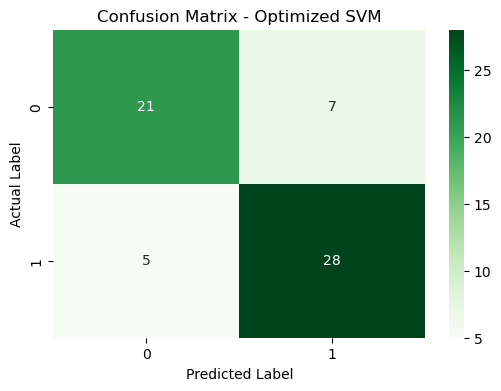

In [89]:
best_svm_cm = confusion_matrix(y_test, best_svm_pred)

plt.figure(figsize=(6,4))
sns.heatmap(best_svm_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Optimized SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [90]:
print("Optimized Classification Report:")
print(classification_report(y_test, best_svm_pred))

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



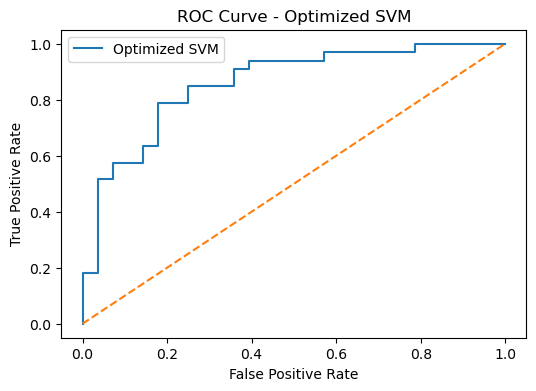

In [91]:
best_svm_fpr, best_svm_tpr, best_svm_thresholds = roc_curve(y_test, best_svm_prob)

plt.figure(figsize=(6,4))
plt.plot(best_svm_fpr, best_svm_tpr, label="Optimized SVM")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized SVM")
plt.legend()
plt.show()

In [92]:
print("===== SVM Model Comparison =====")
print("Original Accuracy:", accuracy_score(y_test, svm_pred))
print("Optimized Accuracy:", accuracy_score(y_test, best_svm_pred))
print("Original F1 Score:", f1_score(y_test, svm_pred))
print("Optimized F1 Score:", f1_score(y_test, best_svm_pred))
print("Original ROC-AUC:", roc_auc_score(y_test, svm_prob))
print("Optimized ROC-AUC:", roc_auc_score(y_test, best_svm_prob))

===== SVM Model Comparison =====
Original Accuracy: 0.7704918032786885
Optimized Accuracy: 0.8032786885245902
Original F1 Score: 0.7941176470588235
Optimized F1 Score: 0.8235294117647058
Original ROC-AUC: 0.841991341991342
Optimized ROC-AUC: 0.8582251082251083


In [93]:
svm_results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": svm_pred
})

svm_results_df.to_csv("svm_predictions.csv", index=False)
print("Saved: svm_predictions.csv")

svm_prob_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": svm_pred,
    "Probability": svm_prob
})

svm_prob_df.to_csv("svm_probabilities.csv", index=False)
print("Saved: svm_probabilities.csv")

svm_metrics_df = pd.DataFrame([{
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, svm_pred),
    "Precision": precision_score(y_test, svm_pred),
    "Recall": recall_score(y_test, svm_pred),
    "F1 Score": f1_score(y_test, svm_pred),
    "ROC-AUC": roc_auc_score(y_test, svm_prob)
}])

svm_metrics_df.to_csv("svm_metrics.csv", index=False)
print("Saved: svm_metrics.csv")

Saved: svm_predictions.csv
Saved: svm_probabilities.csv
Saved: svm_metrics.csv


In [94]:
print("Conclusion:")
print("This notebook applied the Support Vector Machine (SVM) algorithm to the heart disease dataset.")
print("The dataset was preprocessed by checking missing values, removing duplicates, splitting the data, and scaling the features.")
print("The SVM model was trained and evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, Classification Report, and ROC-AUC.")
print("GridSearchCV was then used to tune the SVM hyperparameters and improve performance.")
print("Finally, the predictions and evaluation metrics were saved as CSV files.")
print("This completed the SVM notebook.")

Conclusion:
This notebook applied the Support Vector Machine (SVM) algorithm to the heart disease dataset.
The dataset was preprocessed by checking missing values, removing duplicates, splitting the data, and scaling the features.
The SVM model was trained and evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, Classification Report, and ROC-AUC.
GridSearchCV was then used to tune the SVM hyperparameters and improve performance.
Finally, the predictions and evaluation metrics were saved as CSV files.
This completed the SVM notebook.
